# Bike Sharing Demand — Machine Learning Assignment 1

**Name/Roll No.:** 2026AJ05820

Goal: Predict hourly rental count from weather/time/seasonal data, evaluated on RMSLE.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, pearsonr, spearmanr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
RNG = 42

In [2]:
import os , sys
try:
    import gdown
except ImportError:
    %pip install -q gdown
    import gdown

DATA_DIR="PROCESSED_DATA"
os.makedirs(DATA_DIR, exist_ok=True)
DRIVE_FILES = {
    "bike_train.csv": "18kpPgnoDfOfx3PRRZY3xbsLeWalNViYl",
    "bike_test.csv": "1HJlgPTkGlCzycSTnJNB0oJEfgjSV4o0f",
    "sampleSubmission.csv": "1g_hQQtI80Dz0NkGXG8ZioND9iVGTerd8",
}

for fname, fileid in DRIVE_FILES.items():
  fpath=f"{DATA_DIR}/{fname}"
  if os.path.exists(fpath):
    print(f"Already exits skipping-{fname:22s}")
  else:
    gdown.download(id=fileid,output=fpath,quiet=False)

Already exits skipping-bike_train.csv        
Already exits skipping-bike_test.csv         
Already exits skipping-sampleSubmission.csv  


In [3]:
train_raw=pd.read_csv(f"{DATA_DIR}/bike_train.csv")
test_raw=pd.read_csv(f"{DATA_DIR}/bike_test.csv")
sample_sub=pd.read_csv(f"{DATA_DIR}/sampleSubmission.csv")

print(f"train: {train_raw.shape[0]} rows x {train_raw.shape[1]} columns")
print(f"test: {test_raw.shape[0]} rows x {test_raw.shape[1]} columns")
train_raw.head()

train: 10450 rows x 12 columns
test: 2613 rows x 9 columns


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


## Exploratory Data Analysis (EDA) - 0.5 Marks
Q1. Examine dataset size, missing values, and feature types.

Q2. Visualize relationships between key features and the target variable (count).

Q3. Suggest which variables are likely to be most informative

### Q1 Examine dataset size, missing values and feature types.

In [4]:

train_raw.info()
# Gives the information about the feature types,
# Except Datetime all other columns are numeric,
# Season, holiday workingday weather are categorical codes stored as int64


<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  str    
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   casual      10450 non-null  int64  
 10  registered  10450 non-null  int64  
 11  count       10450 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 979.8 KB


In [5]:
train_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10450.0,2.507943,1.116946,1.00,2.0000,3.00000,4.0000,4.0000
holiday,10450.0,0.028804,0.167263,0.00,0.0000,0.00000,0.0000,1.0000
workingday,10450.0,0.675694,0.468137,0.00,0.0000,1.00000,1.0000,1.0000
weather,10450.0,1.413876,0.632258,1.00,1.0000,1.00000,2.0000,4.0000
temp,10450.0,20.191700,7.792683,0.82,13.9400,20.50000,26.2400,41.0000
atemp,10450.0,23.605793,8.478045,0.76,16.6650,24.24000,31.0600,45.4550
humidity,10450.0,61.924211,19.245193,0.00,47.0000,62.00000,77.0000,100.0000
windspeed,10450.0,12.765259,8.102821,0.00,7.0015,12.45005,16.9979,56.9969
casual,10450.0,35.869091,49.629436,0.00,4.0000,16.00000,49.0000,367.0000
registered,10450.0,154.511675,150.861267,0.00,35.0000,117.00000,221.0000,886.0000


In [6]:
# Checking value counts for categorical-like features
cat_cols = ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
    print(f"--- Value Counts for {col} ---")
    print(train_raw[col].value_counts())
    print("\n")

--- Value Counts for season ---
season
3    2630
4    2630
2    2608
1    2582
Name: count, dtype: int64


--- Value Counts for holiday ---
holiday
0    10149
1      301
Name: count, dtype: int64


--- Value Counts for workingday ---
workingday
1    7061
0    3389
Name: count, dtype: int64


--- Value Counts for weather ---
weather
1    6945
2    2686
3     818
4       1
Name: count, dtype: int64




In [7]:

print(f"Missing values in training set:\n{train_raw.isnull().sum()}")
# finds zero missing values.We also need to confirm about sentinel, that could be possible issue.

Missing values in training set:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [8]:
## DataSet integrity checks (sum validation)

# 1) casual + registered should equal count

difference=((train_raw["casual"] + train_raw["registered"]))-train_raw["count"]
print(f"rows where casual+registered != count : {(difference != 0).sum()} / {len(train_raw)} "
      f"({(difference != 0).mean()*100:.1f}%)")

## casual + registered does not match for 16.4% of rows, and these columns are not present in bike_test.csv,
# so we drop them before modeling.

rows where casual+registered != count : 1709 / 10450 (16.4%)


In [9]:
# presence of duplicate data 
print("duplicate rows:",train_raw.duplicated().sum())
print("duplicated datetimestamp", train_raw['datetime'].duplicated().sum())
# there is no duplicate data in the dataset.

duplicate rows: 0
duplicated datetimestamp 0


In [10]:
# 3) datetime string format validation
print("\ntrain datetime sample:", train_raw["datetime"].iloc[0])
print("test  datetime sample:", test_raw["datetime"].iloc[0])
print("sampleSubmission datetime sample:", sample_sub["datetime"].iloc[0])

# for feature engineering we can use the timestamp object and keep the original format to  writeback to submission file


train datetime sample: 2012-07-15 7:00:00
test  datetime sample: 05-06-2012 5:00
sampleSubmission datetime sample: 05-06-2012 5:00


## Test Train Split  
### Any transform actions eda performed looking at the training dataset.

In [11]:
Feature_cols=["datetime","season","holiday","workingday","weather","temp","atemp","humidity","windspeed"]
Target_col="count"

X = train_raw[Feature_cols].copy()
y = train_raw[Target_col].copy()
insight_extra = train_raw[["casual", "registered"]].copy()

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"X_train:{X_train.shape} X_Val: {X_val.shape}")

X_train:(8360, 9) X_Val: (2090, 9)


In [12]:
# Sentinel / implausible values: "0" can mean the sensor did not record anything, needs to be handled.

num_cols=["temp","atemp","humidity","windspeed"]
sentinel_report=pd.DataFrame({
    "min":X_train[num_cols].min(),
    "max":X_train[num_cols].max(),
    "zero%":(X_train[num_cols]==0).mean().mul(100).round(1),
})
sentinel_report

,min,max,zero%
temp,0.82,41.0000,0.0
atemp,0.76,45.4550,0.0
humidity,0.00,100.0000,0.2
windspeed,0.00,56.9969,11.2


In [13]:
(X_train["humidity"] == 0).sum()

# 17 rows of 8360 humidity=0, an implausible value, treated as sensor failure: convert to nan then median-impute.

np.int64(17)

In [14]:
X_train["weather"].value_counts()
# weather category 4 has only a single example, so the model can't learn much from it. Keep it and one-hot encode it anyway.

weather
1    5570
2    2131
3     658
4       1
Name: count, dtype: int64

## Step 3 — Univariate distribution
Plotting histogram + box plot together. Histogram shows the shape, boxplot shows the outliers.

/tmp/ipykernel_22917/941653382.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(data, vert=False)
/tmp/ipykernel_22917/941653382.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(data, vert=False)
/tmp/ipykernel_22917/941653382.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(data, vert=False)


/tmp/ipykernel_22917/941653382.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(data, vert=False)


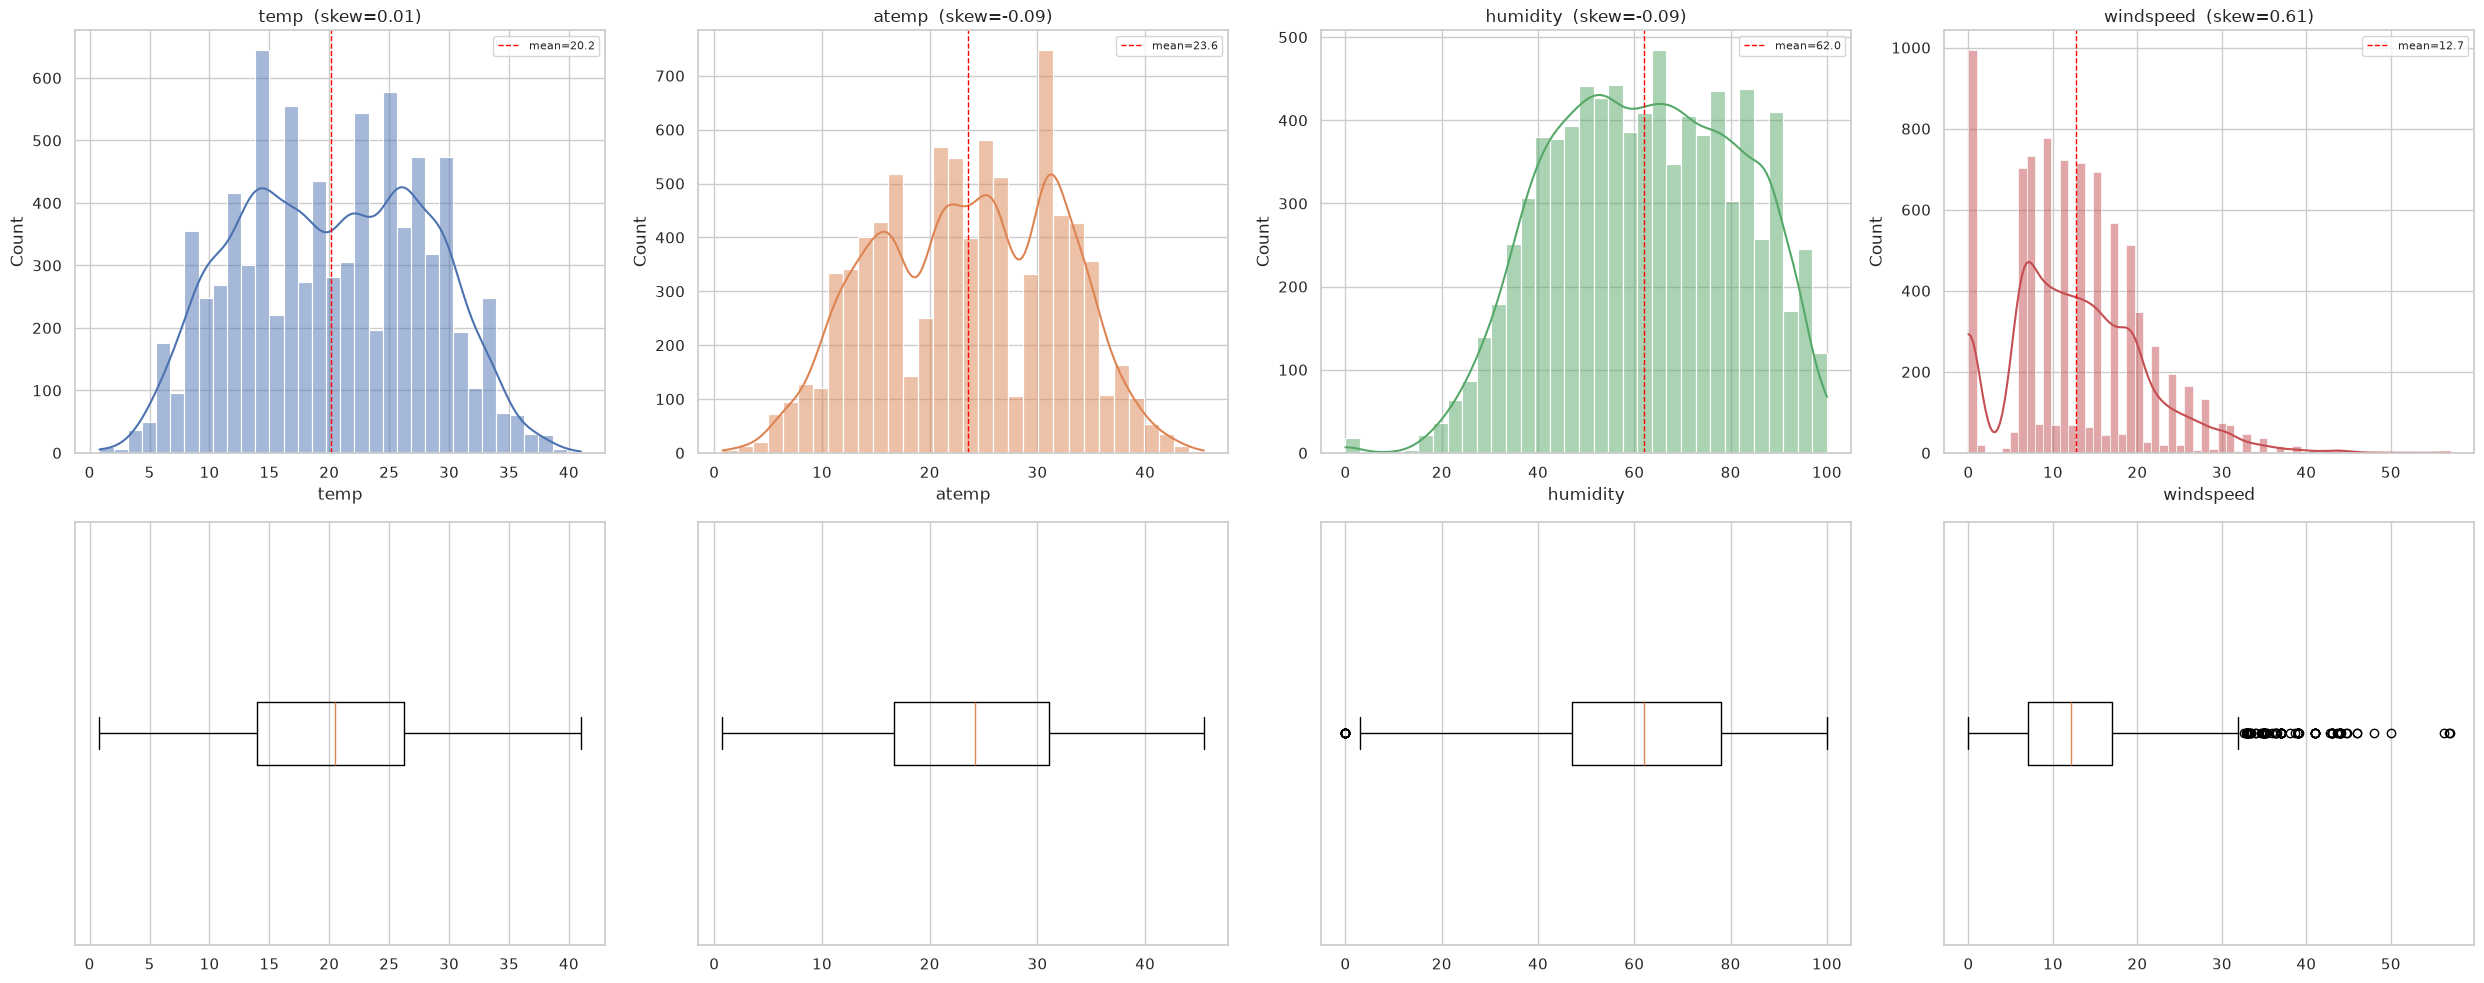

In [15]:
dist_cols = ["temp", "atemp", "humidity", "windspeed"]
fig, axes = plt.subplots(2, len(dist_cols), figsize=(25, 10))
for i, c in enumerate(dist_cols):
    data = X_train[c].dropna()
    sns.histplot(data, kde=True, ax=axes[0, i], color=sns.color_palette("deep")[i])
    axes[0, i].axvline(data.mean(), color="red", ls="--", lw=1, label=f"mean={data.mean():.1f}")
    axes[0, i].set_title(f"{c}  (skew={skew(data):.2f})")
    axes[0, i].legend(fontsize=8)
    axes[1, i].boxplot(data, vert=False)
    axes[1, i].set_yticks([])
plt.tight_layout()
plt.show()

/tmp/ipykernel_22917/4011715460.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(y_train, vert=False)


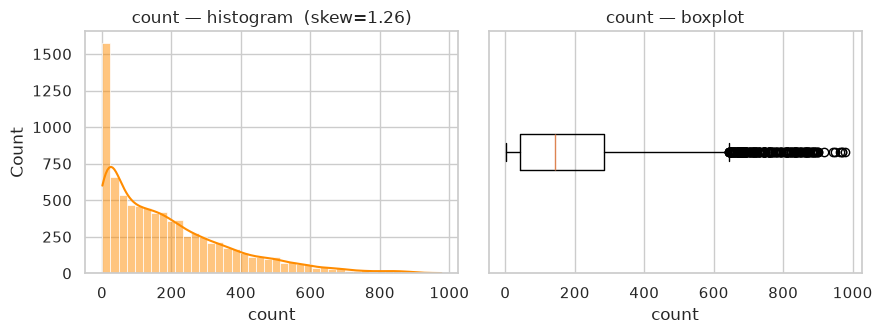

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sns.histplot(y_train, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title(f"count — histogram  (skew={skew(y_train):.2f})")
axes[1].boxplot(y_train, vert=False)
axes[1].set_yticks([]); axes[1].set_xlabel("count")
axes[1].set_title("count — boxplot")
plt.tight_layout()
plt.show()

### Interpretation
`temp`, `atemp`, `humidity` are close to symmetric, healthy shapes — nothing to transform, just scale.
`windspeed` is mildly right-skewed.
`count` (the target) is highly skewed: most hours see a moderate count, with a smaller number of rush hours showing very high demand. Since RMSLE is the scoring metric and is equivalent to modeling `log1p(count)`, we use `log1p(count)` — not raw `count` — as the regression target for better results.

### Categorical Columns
Working towards Q2, to visualize relationships between a few features and the target variable, we analyse the categorical columns.

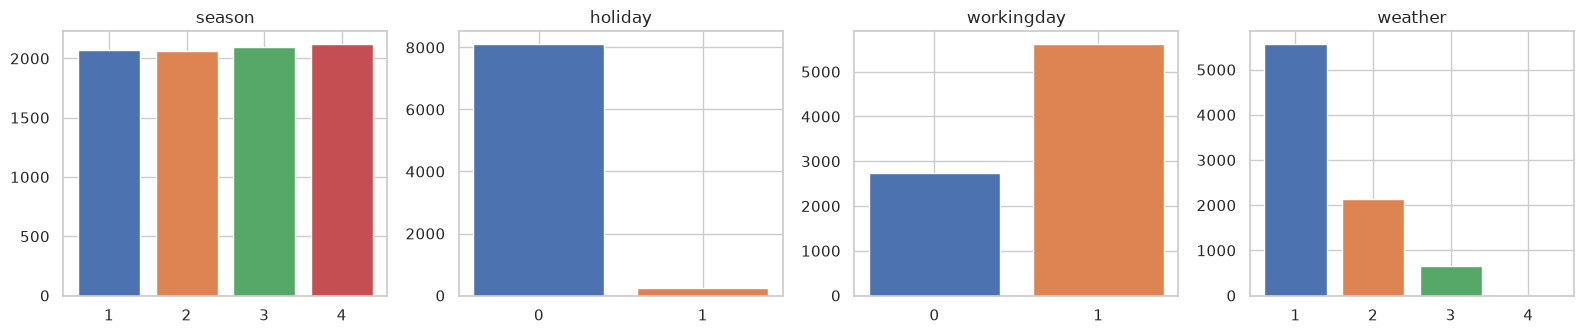

In [17]:
cat_cols = ["season", "holiday", "workingday", "weather"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for c, ax in zip(cat_cols, axes):
    counts = X_train[c].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("deep"))
    ax.set_title(c)
plt.tight_layout()
plt.show()

`holiday` and `weather` are heavily imbalanced categories that need to be handled during transformation and preprocessing.
`season` is nicely balanced, `workingday` is also decently balanced.

#### The raw `datetime` column isn't useful for a regression model as-is
Encoding it into `hour`, `day of week`, and `month` is more helpful — it also lets the model learn whether demand has grown over time (via `year`).

In [18]:
def add_datetime_features(df, dt_col="datetime"):
    df = df.copy()
    dt = df[dt_col]
    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["hour"] = dt.dt.hour
    df["weekday"] = dt.dt.weekday      
    df["is_weekend"] = (df["weekday"] >= 5).astype(int)
    return df

# keep the exact original test string for the submission file, before it gets parsed
test_raw["datetime_original_str"] = test_raw["datetime"]

# train/val datetimes are unambiguous ISO (YYYY-MM-DD) -> parse as-is.
X_train['datetime'] = pd.to_datetime(X_train['datetime'], errors='coerce')
X_val['datetime'] = pd.to_datetime(X_val['datetime'], errors='coerce')

# test datetimes are DD-MM-YYYY (e.g. "05-06-2012" = 5 June) -> dayfirst=True is required here.
# Without it, pandas guesses MM-DD-YYYY: ~38% of rows became NaT (wiping out "hour"), and
# another ~57% silently got day/month swapped (wrong month/weekday/is_weekend).
test_raw['datetime'] = pd.to_datetime(test_raw['datetime'], dayfirst=True, errors='coerce')

X_train = add_datetime_features(X_train)
X_val = add_datetime_features(X_val)
test_raw = add_datetime_features(test_raw)
X_train[["datetime", "year", "month", "hour", "weekday", "is_weekend"]].head()


,datetime,year,month,hour,weekday,is_weekend
7293,2012-12-07 01:00:01,2012,12,1,4,0
3012,2012-08-15 16:00:00,2012,8,16,2,0
6649,2012-10-17 17:00:00,2012,10,17,2,0
9528,2011-10-06 02:00:00,2011,10,2,3,0
7453,2011-10-17 02:00:01,2011,10,2,0,0


In [19]:
class CyclicalEncoder(BaseEstimator, TransformerMixin):
    # code refrence from online documentation
    def __init__(self, period):
        self.period = period

    def fit(self, X, y=None):
        self.n_features_in_ = np.asarray(X).shape[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        theta = 2 * np.pi * X / self.period
        return np.hstack([np.sin(theta), np.cos(theta)])

    def get_feature_names_out(self, input_features=None):
        f = input_features if input_features is not None else [f"x{i}" for i in range(self.n_features_in_)]
        return np.array([f"{n}_sin" for n in f] + [f"{n}_cos" for n in f])

## Step 4 — Feature vs. target relationship (Q2)

Text(0, 0.5, 'mean_count')

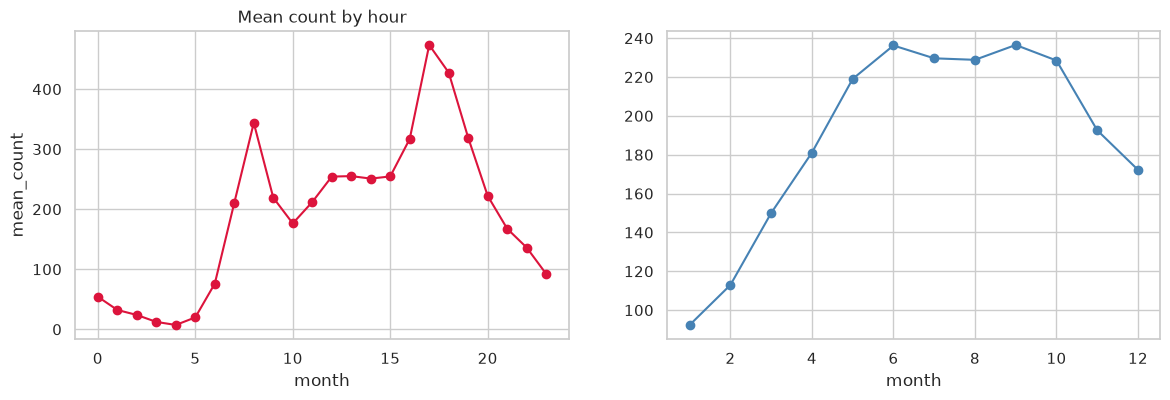

In [20]:
# plotting mean count across each features.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
X_train.assign(count=y_train.values).groupby("hour")["count"].mean().plot(marker="o",ax=axes[0],color="crimson")
axes[0].set_title("Mean count by hour")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("mean_count")

X_train.assign(count=y_train.values).groupby("month")["count"].mean().plot(marker="o",ax=axes[1],color='steelblue')
axes[0].set_title("Mean count by hour")
axes[0].set_xlabel("month")
axes[0].set_ylabel("mean_count")

***hour***: rides shoot up during the morning hours, with the sharpest jump around 7-8am (office/school commute), followed by a mid-day plateau and an evening spike higher than the morning one, then a steady decline from 7pm through overnight.

A linear fit doesn't work for `hour` — the relationship is not linear, and this double peak needs to be handled explicitly. A log transform won't help either, since log is monotonic and can't reshape a two-peak curve. `hour` can instead be represented with one-hot encoding or cyclical sine/cosine encoding, so the model can capture its non-linear, repeating nature.

We try three cases — raw `hour`, one-hot encoded `hour`, and sin/cos encoded `hour` — and compare the results.

***month***: non-monotonic — it climbs steadily through the summer months and drops in winter. Cyclic encoding helps here too, since month is also periodic.


In [21]:
## Try analyse the plots by the working day and see if we can get any better results,


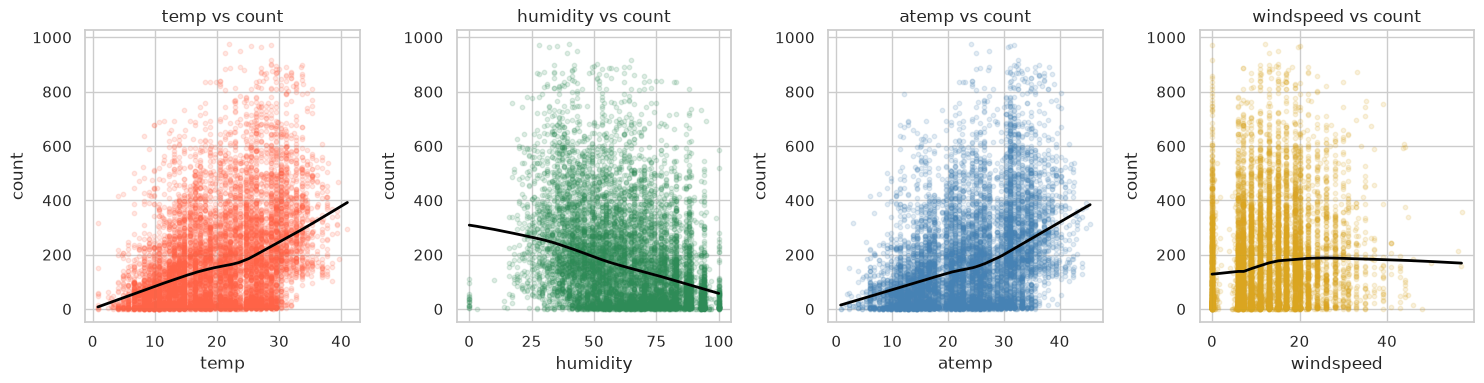

In [22]:
## Q2 continued: scatter plots showing the actual shape of the relationship — plot temp, humidity, windspeed, atemp
# against count on the training hold with a trend line.

fig,axes=plt.subplots(1,4,figsize=(15,4))
num_cols=["temp","humidity","atemp","windspeed"]
colors = ["tomato", "seagreen", "steelblue","goldenrod"]
for ax, c, color in zip(axes, num_cols, colors):
    s = X_train[c]
    yy = y_train
    mask = s.notna()
    sns.regplot(x=s[mask], y=yy[mask], ax=ax, scatter_kws={"alpha": 0.15, "s": 10, "color": color},
                line_kws={"color": "black", "lw": 2}, lowess=True)
    ax.set_title(f"{c} vs count")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()



`temp` vs `count`: the trend line rises with temperature — warmer weather means more people rent bikes.
`humidity` vs `count`: higher humidity is associated with fewer riders.
`windspeed` vs `count`: very weak correlation, an almost flat line — windspeed has little impact on rider count.


In [23]:
# Analysing categorical count vs features,

X_train.info()
                                                                                                                                                                                                                                                                                                        

<class 'pandas.DataFrame'>
Index: 8360 entries, 7293 to 7270
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    8360 non-null   datetime64[us]
 1   season      8360 non-null   int64         
 2   holiday     8360 non-null   int64         
 3   workingday  8360 non-null   int64         
 4   weather     8360 non-null   int64         
 5   temp        8360 non-null   float64       
 6   atemp       8360 non-null   float64       
 7   humidity    8360 non-null   int64         
 8   windspeed   8360 non-null   float64       
 9   year        8360 non-null   int32         
 10  month       8360 non-null   int32         
 11  hour        8360 non-null   int32         
 12  weekday     8360 non-null   int32         
 13  is_weekend  8360 non-null   int64         
dtypes: datetime64[us](1), float64(3), int32(4), int64(6)
memory usage: 849.1 KB


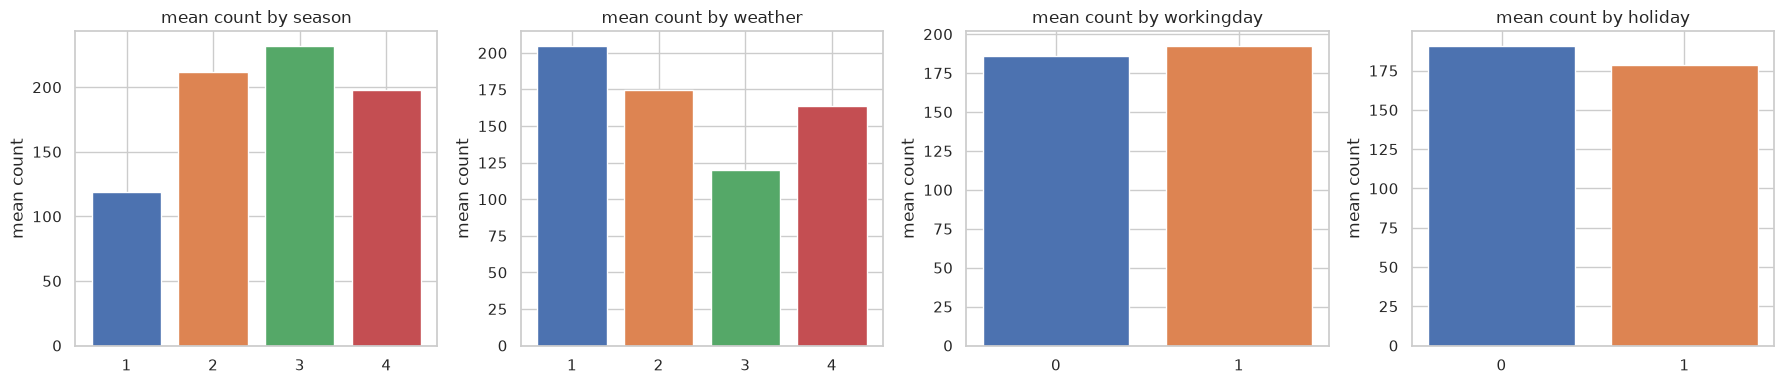

In [24]:
cat_feats = ["season", "weather", "workingday", "holiday"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, cat_feats):
    means = X_train.assign(count=y_train.values).groupby(c)["count"].mean().sort_index()
    ax.bar(means.index.astype(str), means.values, color=sns.color_palette("deep"))
    ax.set_title(f"mean count by {c}")
    ax.set_ylabel("mean count")
plt.tight_layout()
plt.show()

***Season*** and ***weather*** show a clear, visible effect on `count`. In these bar charts ***workingday*** and ***holiday*** look flat on their own, but `workingday` becomes useful once combined with ***hour***.

#### Q3: most informative variables
1. `hour` (especially combined with `workingday`): strongest driver — the two-peak commute pattern separates high and low demand.
2. `temp`/`atemp`: roughly linear relationship — warmer weather, more riders.
3. `humidity`: moderately related — more humid weather, fewer riders.
4. `season`/`month`: clear seasonal cycle — low in winter, high in summer.
5. `year`: steady growth over time.
6. `workingday`: combined with `hour` it contributes useful information.
7. `windspeed`: worth keeping, but not much information — the plot was nearly flat.
8. `holiday`: low priority.

## Step 5 — Between-features correlations

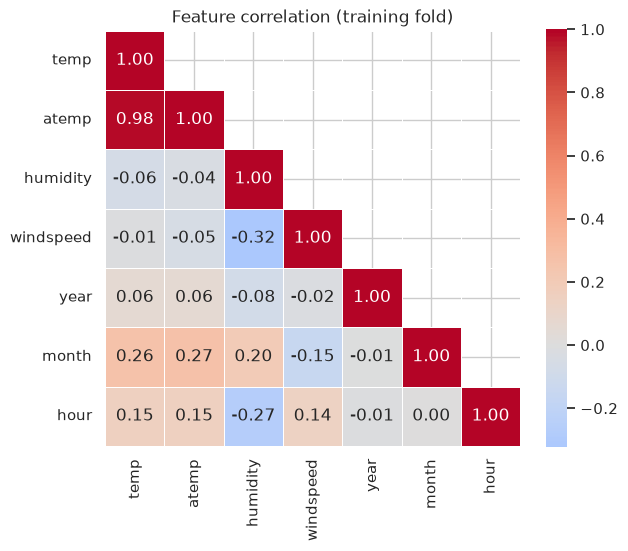

In [25]:
corr_cols = ["temp", "atemp", "humidity", "windspeed", "year", "month", "hour"]
corr = X_train[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
# we als1 dont want the releative upper triangular matrix, lets hide it
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask , annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
plt.title("Feature correlation (training fold)")
plt.tight_layout()
plt.show()

`temp` and `atemp` correlate at 0.98 — near-perfect correlation. We keep `temp` and drop `atemp`; no other redundancy to remove.

In [26]:
DROP_COLS=["atemp"]

## Step 6 — Outlier detection (as covered in Module 2 of Machine Learning)

In [27]:
def iqr_outlier_stats(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = s[(s < lo) | (s > hi)]
    return len(flagged), len(flagged) / len(s) * 100, lo, hi

for name, s in [("windspeed", X_train["windspeed"]), ("humidity", X_train["humidity"].dropna()),
                 ("count", y_train)]:
    n, pct, lo, hi = iqr_outlier_stats(s)
    print(f"{name:10s}: {n:4d} outliers ({pct:4.1f}%)  bounds=[{lo:.1f}, {hi:.1f}]")

windspeed :  159 outliers ( 1.9%)  bounds=[-8.0, 32.0]
humidity  :   17 outliers ( 0.2%)  bounds=[0.5, 124.5]
count     :  228 outliers ( 2.7%)  bounds=[-319.5, 644.5]



##### Windspeed
`windspeed` cannot be negative. We reduce its leverage on the fit by applying **RobustScaler**.

##### Count
We model `log1p(count)` instead of raw `count` (the target). This reduces skewness and the influence of extremely large rental counts, which helps the fit.


### Scaling the data

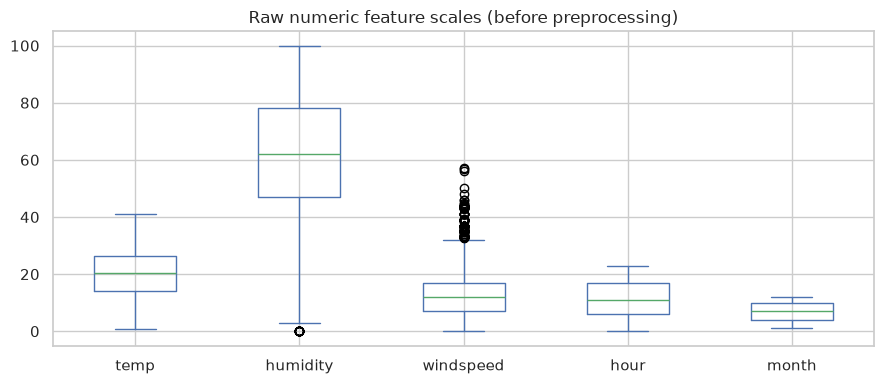

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))
X_train[["temp", "humidity", "windspeed", "hour", "month"]].plot(kind="box", ax=ax)
plt.title("Raw numeric feature scales (before preprocessing)")
plt.tight_layout()
plt.show()

`humidity` (0-100) dwarfs `hour` (0-23) and `month` (0-12) by scale, with `temp` and `windspeed` squeezed near the bottom.
Any distance-based model would let `humidity` dominate purely because of its scale, so we need to scale everything.
`windspeed` has a handful of points outside the outlier bounds (checked above), so we apply `RobustScaler` to it.

## Building Preprocessing Pipeline

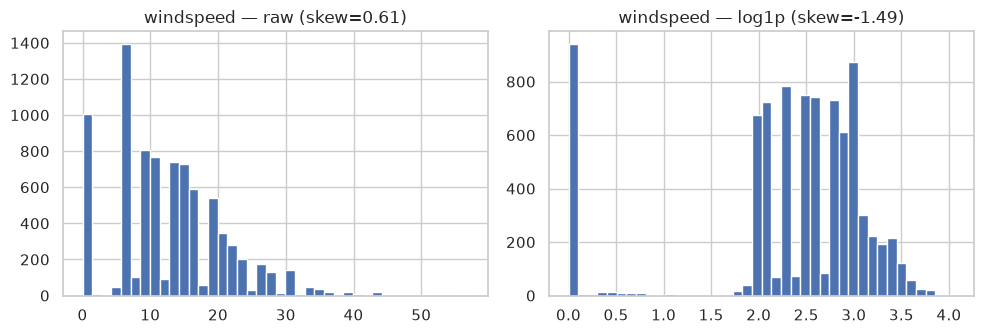

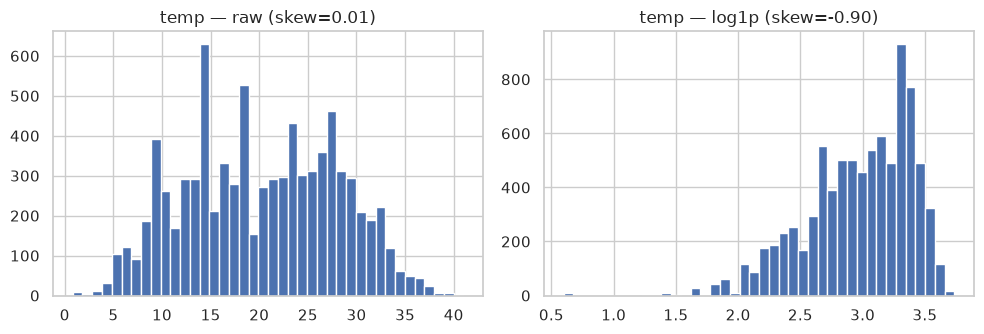

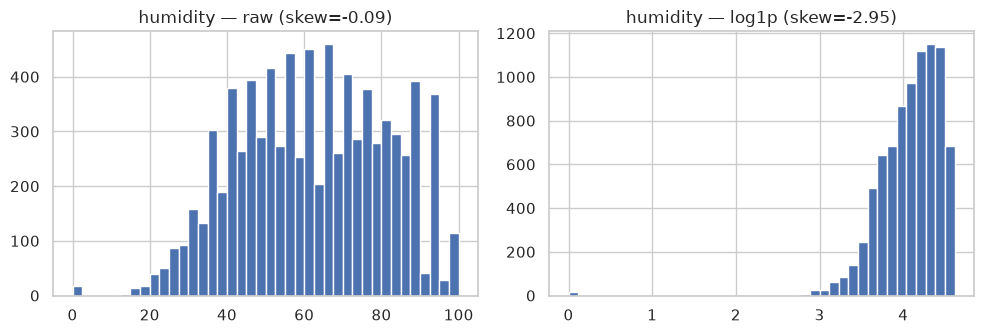

In [29]:
## Before building preprocessing pipeline i want to analyse the impact of transform and even is it worth applying

# first plotting for windspeed and analyse
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
X_train["windspeed"].hist(bins=40, ax=axes[0])
axes[0].set_title(f"windspeed — raw (skew={skew(X_train['windspeed']):.2f})")
np.log1p(X_train["windspeed"]).hist(bins=40, ax=axes[1])
axes[1].set_title(f"windspeed — log1p (skew={skew(np.log1p(X_train['windspeed'])):.2f})")
plt.tight_layout()
plt.show()

## log1p makes things worse, not better. We do not apply the transformation, and use RobustScaler instead of
## StandardScaler.

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
X_train["temp"].hist(bins=40, ax=axes[0])
axes[0].set_title(f"temp — raw (skew={skew(X_train['temp']):.2f})")
np.log1p(X_train["temp"]).hist(bins=40, ax=axes[1])
axes[1].set_title(f"temp — log1p (skew={skew(np.log1p(X_train['temp'])):.2f})")
plt.tight_layout()
plt.show()

## temp is already symmetric and healthy, no transform needed — apply StandardScaler.

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
X_train["humidity"].hist(bins=40, ax=axes[0])
axes[0].set_title(f"humidity — raw (skew={skew(X_train['humidity']):.2f})")
np.log1p(X_train["humidity"]).hist(bins=40, ax=axes[1])
axes[1].set_title(f"humidity — log1p (skew={skew(np.log1p(X_train['humidity'])):.2f})")
plt.tight_layout()
plt.show()

# humidity is also fine as-is — apply StandardScaler, no transform needed.

### Decisions
**Numerical columns**
- `temp`: StandardScaler
- `humidity`: median-impute, then StandardScaler
- `windspeed`: RobustScaler, no transform

**Categorical / other columns**
- `season`, `weather`, `workingday`, `holiday`, `year`: small cardinality, one-hot encode
- `hour`, `month`, `weekday`: periodic, cyclical sin/cos encode
- `is_weekend`: already binary, passthrough
- `atemp`: 0.98 correlated with `temp`, dropped
- `casual`, `registered`: not present in `bike_test.csv`, dropped
- `count` (target): model `log1p(count)`, invert at prediction time

In [30]:

ONEHOT_COLS = ["season", "weather", "workingday", "holiday", "year"]
STANDARD_COLS = ["temp", "humidity"]
ROBUST_COLS = ["windspeed"]
PASSTHROUGH_COLS = ["is_weekend"]

CYCLICAL_COLS = {
    "hour": 24,
    "month": 12,
    "weekday": 7,
}


def build_preprocessor():
    """Create the feature preprocessing pipeline."""

    transformers = [
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            ONEHOT_COLS,
        ),


        (
            "standard",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            STANDARD_COLS,
        ),

        (
            "robust",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler()),
            ]),
            ROBUST_COLS,
        ),

        (
            "passthrough",
            "passthrough",
            PASSTHROUGH_COLS,
        ),
    ]

    for column, period in CYCLICAL_COLS.items():
        transformers.append(
            (
                f"cyclical_{column}",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("encoder", CyclicalEncoder(period)),
                ]),
                [column],
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


preprocessor = build_preprocessor()

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(test_raw)



feature_names = preprocessor.get_feature_names_out()

assert not (set(DROP_COLS) & set(feature_names)), \
    "A dropped column leaked into the pipeline output."

assert not ({"casual", "registered"} & set(feature_names)), \
    "Leakage columns reached the pipeline."


print("Processed feature count:", len(feature_names))
print("Features:", list(feature_names))

print("\nShapes:")
print("Train:", X_train_proc.shape)
print("Validation:", X_val_proc.shape)
print("Test:", X_test_proc.shape)

Processed feature count: 24
Features: ['season_1', 'season_2', 'season_3', 'season_4', 'weather_1', 'weather_2', 'weather_3', 'weather_4', 'workingday_0', 'workingday_1', 'holiday_0', 'holiday_1', 'year_2011', 'year_2012', 'temp', 'humidity', 'windspeed', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']

Shapes:
Train: (8360, 24)
Validation: (2090, 24)
Test: (2613, 24)


### Save the processed artifacts: easier for modeling and training in the next steps



In [31]:
import joblib

pd.DataFrame(X_train_proc, columns=feature_names).to_csv(f"{DATA_DIR}/bike_train_X_processed.csv", index=False)
pd.DataFrame(X_val_proc, columns=feature_names).to_csv(f"{DATA_DIR}/bike_val_X_processed.csv", index=False)
pd.DataFrame(X_test_proc, columns=feature_names).to_csv(f"{DATA_DIR}/bike_test_X_processed.csv", index=False)

y_train.to_csv(f"{DATA_DIR}/bike_train_y.csv", index=False)
y_val.to_csv(f"{DATA_DIR}/bike_val_y.csv", index=False)
np.log1p(y_train).to_csv(f"{DATA_DIR}/bike_train_y_log1p.csv", index=False)
np.log1p(y_val).to_csv(f"{DATA_DIR}/bike_val_y_log1p.csv", index=False)

# original test datetimes, untouched, for the eventual submission.csv
test_raw[["datetime_original_str"]].to_csv(f"{DATA_DIR}/bike_test_datetime_for_submission.csv", index=False)

joblib.dump(preprocessor, f"{DATA_DIR}/bike_preprocessor.joblib")

['PROCESSED_DATA/bike_preprocessor.joblib']

### Q4 

- **Derived from `datetime`:** `year`, `month`, `hour`, `weekday`, `is_weekend`.
- **Cyclical (sin/cos) encoding** for `hour` (period 24), `month` (period 12), `weekday`
  (period 7) — a plain integer would tell the model hour 23 and hour 0 are far apart when
  they're actually one hour of clock time apart, and cyclic encoding fixes that.
- **One-hot encoding** for the low-cardinality categoricals: `season`, `weather`,
  `workingday`, `holiday`, `year` (`handle_unknown="ignore"` so an unseen category at
  prediction time doesn't crash the pipeline).
- **Transform decisions made empirically, not by assumption:** `windspeed` was tested with
  `log1p` and `sqrt` — both *worsened* skew and correlation with `count` versus leaving it
  raw, so it is scaled with `RobustScaler` untransformed. `temp`/`humidity` get a plain
  `StandardScaler`. `atemp` is dropped (0.98 correlated with `temp`).
- **Target transform:** `count` → `log1p(count)`, justified directly by the RMSLE formula
  above, not by skew alone.


In [32]:
def rmsle(y_true,y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def evaluate(model,X_tr,X_va,y_tr_log,y_tr_actual,y_va_actual):
    model.fit(X_tr,y_tr_log)
    pred_tr=np.clip(np.expm1(model.predict(X_tr)),0,None)
    pred_va=np.clip(np.expm1(model.predict(X_va)),0,None)

    return {
        "model":model,
        "train_rmsle": rmsle(y_tr_actual,pred_tr),
        "val_rmsle": rmsle(y_va_actual,pred_va),
        "pred_va": pred_va,
    }

## Loading the finalized preprocessed data

In [33]:
X_train_proc = pd.read_csv("PROCESSED_DATA/bike_train_X_processed.csv")
X_val_proc = pd.read_csv("PROCESSED_DATA/bike_val_X_processed.csv")
X_test_proc = pd.read_csv("PROCESSED_DATA/bike_test_X_processed.csv")

y_train = pd.read_csv("PROCESSED_DATA/bike_train_y.csv")["count"]
y_val = pd.read_csv("PROCESSED_DATA/bike_val_y.csv")["count"]
y_train_log1p = pd.read_csv("PROCESSED_DATA/bike_train_y_log1p.csv")["count"]
y_val_log1p = pd.read_csv("PROCESSED_DATA/bike_val_y_log1p.csv")["count"]

test_datetime_for_submission = pd.read_csv("PROCESSED_DATA/bike_test_datetime_for_submission.csv")
FEATURE_NAMES = list(X_train_proc.columns)
print("features:", len(FEATURE_NAMES))
print(FEATURE_NAMES)
print("\nshapes -> train:", X_train_proc.shape, " val:", X_val_proc.shape,
      " test:", X_test_proc.shape)

features: 24
['season_1', 'season_2', 'season_3', 'season_4', 'weather_1', 'weather_2', 'weather_3', 'weather_4', 'workingday_0', 'workingday_1', 'holiday_0', 'holiday_1', 'year_2011', 'year_2012', 'temp', 'humidity', 'windspeed', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']

shapes -> train: (8360, 24)  val: (2090, 24)  test: (2613, 24)


## Q5 Train/validation split + simple linear regression
We already split the dataset during the preprocessing.

In [34]:
from sklearn.linear_model import LinearRegression
res_linear_base=evaluate(LinearRegression(),X_train_proc,X_val_proc,y_train_log1p,y_train,y_val)
print(f"Linear Regression: (no poly)")
print(f" train RMSLE: {res_linear_base['train_rmsle']:.4f}")
print(f" val RMSLE: {res_linear_base['val_rmsle']:.4f}")


Linear Regression: (no poly)
 train RMSLE: 0.8909
 val RMSLE: 0.8699


Train and val RMSLE come out close to each other — this is underfitting, a linear model can't bend to fit the two-peak commute pattern in `hour`. We need polynomial features to fit this data better.

## Q6 — Extending the feature space and regularizing

To improve on the underfitting linear baseline, we extend the feature space with polynomial transformations (degree 2, then degree 3) on the continuous/cyclical columns, and apply Ridge and Lasso regression on top with the regularization strength (`alpha`) tuned by cross-validation rather than guessed.

In [35]:
from sklearn.preprocessing import PolynomialFeatures
NUMERIC_FOR_POLY = ["temp", "humidity", "windspeed",
                    "hour_sin", "hour_cos", "month_sin", "month_cos",
                    "weekday_sin", "weekday_cos"]
CAT_COLS = [c for c in FEATURE_NAMES if c not in NUMERIC_FOR_POLY]
print("categorical/passthrough columns kept linear:", len(CAT_COLS))
print("numeric columns expanded polynomially:", len(NUMERIC_FOR_POLY))


def make_poly_features(degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    tr_num = poly.fit_transform(X_train_proc[NUMERIC_FOR_POLY])
    va_num = poly.transform(X_val_proc[NUMERIC_FOR_POLY])
    te_num = poly.transform(X_test_proc[NUMERIC_FOR_POLY])
    Xtr = np.hstack([X_train_proc[CAT_COLS].values, tr_num])
    Xva = np.hstack([X_val_proc[CAT_COLS].values, va_num])
    Xte = np.hstack([X_test_proc[CAT_COLS].values, te_num])
    return poly, Xtr, Xva, Xte


poly2, Xtr_poly2, Xva_poly2, Xte_poly2 = make_poly_features(degree=2)
print("\ndegree-2 feature count:", Xtr_poly2.shape[1],
      f"(from {len(CAT_COLS)} categorical + {Xtr_poly2.shape[1] - len(CAT_COLS)} polynomial)")

categorical/passthrough columns kept linear: 15
numeric columns expanded polynomially: 9

degree-2 feature count: 69 (from 15 categorical + 54 polynomial)


In [36]:
res_poly2_plain = evaluate(LinearRegression(), Xtr_poly2, Xva_poly2,
                            y_train_log1p, y_train, y_val)
print("Polynomial (deg=2) + plain Linear Regression, no regularization")
print(f"  train RMSLE: {res_poly2_plain['train_rmsle']:.4f}")
print(f"  val   RMSLE: {res_poly2_plain['val_rmsle']:.4f}")

Polynomial (deg=2) + plain Linear Regression, no regularization
  train RMSLE: 0.6953
  val   RMSLE: 0.6769


In [37]:
from sklearn.linear_model import RidgeCV
ridge_alphas = np.logspace(-3, 4, 30)
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=5)
res_poly2_ridge = evaluate(ridge_cv, Xtr_poly2, Xva_poly2, y_train_log1p, y_train, y_val)
print(f"Polynomial (deg=2) + RidgeCV  ->  best alpha = {ridge_cv.alpha_:.4g}")
print(f"  train RMSLE: {res_poly2_ridge['train_rmsle']:.4f}")
print(f"  val   RMSLE: {res_poly2_ridge['val_rmsle']:.4f}")

Polynomial (deg=2) + RidgeCV  ->  best alpha = 12.69
  train RMSLE: 0.6954
  val   RMSLE: 0.6766


In [38]:
from sklearn.linear_model import LassoCV
lasso_alphas = np.logspace(-4, 1, 20)
lasso_cv = LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000, random_state=RNG)
res_poly2_lasso = evaluate(lasso_cv, Xtr_poly2, Xva_poly2, y_train_log1p, y_train, y_val)
n_zeroed = int((lasso_cv.coef_ == 0).sum())
print(f"Polynomial (deg=2) + LassoCV  ->  best alpha = {lasso_cv.alpha_:.4g}")
print(f"  train RMSLE: {res_poly2_lasso['train_rmsle']:.4f}")
print(f"  val   RMSLE: {res_poly2_lasso['val_rmsle']:.4f}")

Polynomial (deg=2) + LassoCV  ->  best alpha = 0.0006158
  train RMSLE: 0.6955
  val   RMSLE: 0.6766


In [39]:
poly3, Xtr_poly3, Xva_poly3, Xte_poly3 = make_poly_features(degree=3)
print(f"degree-3 feature count: {Xtr_poly3.shape[1]}")

res_poly3_plain = evaluate(LinearRegression(), Xtr_poly3, Xva_poly3,
                            y_train_log1p, y_train, y_val)
print("\nPolynomial (deg=3) + plain Linear Regression, no regularization")
print(f"  train RMSLE: {res_poly3_plain['train_rmsle']:.4f}")
print(f"  val   RMSLE: {res_poly3_plain['val_rmsle']:.4f}")

ridge3_cv = RidgeCV(alphas=ridge_alphas, cv=5)
res_poly3_ridge = evaluate(ridge3_cv, Xtr_poly3, Xva_poly3, y_train_log1p, y_train, y_val)
print(f"\nPolynomial (deg=3) + RidgeCV  ->  best alpha = {ridge3_cv.alpha_:.4g}")
print(f"  train RMSLE: {res_poly3_ridge['train_rmsle']:.4f}")
print(f"  val   RMSLE: {res_poly3_ridge['val_rmsle']:.4f}")

degree-3 feature count: 234



Polynomial (deg=3) + plain Linear Regression, no regularization
  train RMSLE: 0.5196
  val   RMSLE: 0.5227



Polynomial (deg=3) + RidgeCV  ->  best alpha = 12.69
  train RMSLE: 0.5199
  val   RMSLE: 0.5219


### Additional tries to improve the RMSLE score
Try adding an `hour * workingday` interaction term — this could help the model understand the commute peaks on working days, and see if RMSLE improves.

In [40]:
workingday_flag = X_train_proc["workingday_1"].values
workingday_flag_va = X_val_proc["workingday_1"].values
workingday_flag_te = X_test_proc["workingday_1"].values

interact_tr = np.column_stack([
    X_train_proc["hour_sin"].values * workingday_flag,
    X_train_proc["hour_cos"].values * workingday_flag,
])
interact_va = np.column_stack([
    X_val_proc["hour_sin"].values * workingday_flag_va,
    X_val_proc["hour_cos"].values * workingday_flag_va,
])
interact_te = np.column_stack([
    X_test_proc["hour_sin"].values * workingday_flag_te,
    X_test_proc["hour_cos"].values * workingday_flag_te,
])

Xtr_poly3_inter = np.hstack([Xtr_poly3, interact_tr])
Xva_poly3_inter = np.hstack([Xva_poly3, interact_va])
Xte_poly3_inter = np.hstack([Xte_poly3, interact_te])

ridge3_inter_cv = RidgeCV(alphas=ridge_alphas, cv=5)
res_poly3_ridge_inter = evaluate(ridge3_inter_cv, Xtr_poly3_inter, Xva_poly3_inter,
                                  y_train_log1p, y_train, y_val)
print(f"Polynomial (deg=3) + hour*workingday interactions + RidgeCV "
      f"-> best alpha = {ridge3_inter_cv.alpha_:.4g}")
print(f"  train RMSLE: {res_poly3_ridge_inter['train_rmsle']:.4f}")
print(f"  val   RMSLE: {res_poly3_ridge_inter['val_rmsle']:.4f}")

Polynomial (deg=3) + hour*workingday interactions + RidgeCV -> best alpha = 7.279
  train RMSLE: 0.5186
  val   RMSLE: 0.5219


### The previous attempt (`hour_sin * workingday`) tried to patch this, but the term only multiplies the whole sine wave by one scalar. It can make the curve taller or shorter on workdays, but it cannot move the peak, split it into two, or change its shape.

`make_hour_workingday_cross` instead builds a string key like `"17_1"` (hour 17, workingday=1) and one-hot encodes it. This lets the model learn the workday double-peak and the weekend single midday hump simultaneously, as two genuinely independent shapes.

In [41]:
def make_hour_workingday_cross(hour, workingday, columns=None):
    key = pd.Series(hour).astype(str) + "_" + pd.Series(workingday).astype(str)
    dummies = pd.get_dummies(key)
    if columns is not None:
        dummies = dummies.reindex(columns=columns, fill_value=0)
    return dummies



hour_tr = X_train["hour"].values
hour_va = X_val["hour"].values
wd_tr_raw = X_train["workingday"].values
wd_va_raw = X_val["workingday"].values

cross_tr = make_hour_workingday_cross(hour_tr, wd_tr_raw)
cross_va = make_hour_workingday_cross(hour_va, wd_va_raw, columns=cross_tr.columns)
print("hour x workingday cross columns:", cross_tr.shape[1])


CROSS_CAT_COLS = ["season_1", "season_2", "season_3", "season_4",
                   "weather_1", "weather_2", "weather_3", "weather_4",
                   "holiday_0", "holiday_1", "year_2011", "year_2012", "is_weekend"]
CONT_COLS = ["temp", "humidity", "windspeed"]
CYCLIC_REST_COLS = ["month_sin", "month_cos", "weekday_sin", "weekday_cos"]

cross_results = {}
for degree in (1, 2, 3):
    poly_cont = PolynomialFeatures(degree=degree, include_bias=False)
    cont_tr = poly_cont.fit_transform(X_train_proc[CONT_COLS])
    cont_va = poly_cont.transform(X_val_proc[CONT_COLS])
    Xtr_cross = np.hstack([X_train_proc[CROSS_CAT_COLS].values, cross_tr.values, cont_tr,
                            X_train_proc[CYCLIC_REST_COLS].values])
    Xva_cross = np.hstack([X_val_proc[CROSS_CAT_COLS].values, cross_va.values, cont_va,
                            X_val_proc[CYCLIC_REST_COLS].values])

    ridge_cross_cv = RidgeCV(alphas=np.logspace(-3, 4, 30), cv=5)
    res = evaluate(ridge_cross_cv, Xtr_cross, Xva_cross, y_train_log1p, y_train, y_val)
    cross_results[degree] = {"poly": poly_cont, "model": ridge_cross_cv,
                              "Xtr": Xtr_cross, "Xva": Xva_cross, **res}
    print(f"cross + continuous deg={degree}: n_features={Xtr_cross.shape[1]}  "
          f"alpha={ridge_cross_cv.alpha_:.3g}  "
          f"train RMSLE={res['train_rmsle']:.4f}  val RMSLE={res['val_rmsle']:.4f}")

hour x workingday cross columns: 48


cross + continuous deg=1: n_features=68  alpha=0.259  train RMSLE=0.4216  val RMSLE=0.4271


cross + continuous deg=2: n_features=74  alpha=0.149  train RMSLE=0.4095  val RMSLE=0.4117


cross + continuous deg=3: n_features=84  alpha=0.149  train RMSLE=0.4044  val RMSLE=0.4104


### This categorical cross model beats every model from the previous section, and degree 3 is the best of the three. Even the sin/cos interaction didn't help, but treating (`hour`, `workingday`) as an independent categorical pair was able to fit the data far better.

## Q7 Model Comparison Table


In [42]:
results_table = pd.DataFrame([
    {"model": "Linear Regression (24 features, no poly)",
     "n_features": X_train_proc.shape[1],
     "train_rmsle": res_linear_base["train_rmsle"], "val_rmsle": res_linear_base["val_rmsle"],
     "key observation": "underfits — closest train/val gap, worst val score"},
    {"model": "Polynomial deg=2 + Linear Regression",
     "n_features": Xtr_poly2.shape[1],
     "train_rmsle": res_poly2_plain["train_rmsle"], "val_rmsle": res_poly2_plain["val_rmsle"],
     "key observation": "overfits — best train score, worse val score than regularized poly"},
    {"model": "Polynomial deg=2 + Ridge (tuned)",
     "n_features": Xtr_poly2.shape[1],
     "train_rmsle": res_poly2_ridge["train_rmsle"], "val_rmsle": res_poly2_ridge["val_rmsle"],
     "key observation": f"alpha={ridge_cv.alpha_:.3g}, shrinks all coefficients"},
    {"model": "Polynomial deg=2 + Lasso (tuned)",
     "n_features": Xtr_poly2.shape[1],
     "train_rmsle": res_poly2_lasso["train_rmsle"], "val_rmsle": res_poly2_lasso["val_rmsle"],
     "key observation": f"alpha={lasso_cv.alpha_:.3g}, zeroed {n_zeroed} coefficients"},
    {"model": "Polynomial deg=3 + Linear Regression",
     "n_features": Xtr_poly3.shape[1],
     "train_rmsle": res_poly3_plain["train_rmsle"], "val_rmsle": res_poly3_plain["val_rmsle"],
     "key observation": "best train score of all models, but val gap shows it's overfitting"},
    {"model": "Polynomial deg=3 + Ridge (tuned)",
     "n_features": Xtr_poly3.shape[1],
     "train_rmsle": res_poly3_ridge["train_rmsle"], "val_rmsle": res_poly3_ridge["val_rmsle"],
     "key observation": f"alpha={ridge3_cv.alpha_:.3g}"},
    {"model": "Polynomial deg=3 + hour*workingday + Ridge (tuned)",
     "n_features": Xtr_poly3_inter.shape[1],
     "train_rmsle": res_poly3_ridge_inter["train_rmsle"], "val_rmsle": res_poly3_ridge_inter["val_rmsle"],
     "key observation": f"alpha={ridge3_inter_cv.alpha_:.3g}, explicit hour x workingday terms"},
    *[
        {"model": f"Hour x Workingday cross + poly deg={d} + Ridge (tuned)",
         "n_features": cross_results[d]["Xtr"].shape[1],
         "train_rmsle": cross_results[d]["train_rmsle"], "val_rmsle": cross_results[d]["val_rmsle"],
         "key observation": f"alpha={cross_results[d]['model'].alpha_:.3g}, 48 free hour x workingday coefficients"}
        for d in (1, 2, 3)
    ],
])
results_table = results_table.sort_values("val_rmsle").reset_index(drop=True)
results_table

,model,n_features,train_rmsle,val_rmsle,key observation
0,Hour x Workingday cross + poly deg=3 + Ridge (...,84,0.404425,0.410390,"alpha=0.149, 48 free hour x workingday coeffic..."
1,Hour x Workingday cross + poly deg=2 + Ridge (...,74,0.409527,0.411707,"alpha=0.149, 48 free hour x workingday coeffic..."
2,Hour x Workingday cross + poly deg=1 + Ridge (...,68,0.421578,0.427112,"alpha=0.259, 48 free hour x workingday coeffic..."
3,Polynomial deg=3 + hour*workingday + Ridge (tu...,236,0.518584,0.521874,"alpha=7.28, explicit hour x workingday terms"
4,Polynomial deg=3 + Ridge (tuned),234,0.519923,0.521902,alpha=12.7
5,Polynomial deg=3 + Linear Regression,234,0.519583,0.522702,"best train score of all models, but val gap sh..."
6,Polynomial deg=2 + Lasso (tuned),69,0.695511,0.676640,"alpha=0.000616, zeroed 13 coefficients"
7,Polynomial deg=2 + Ridge (tuned),69,0.695423,0.676640,"alpha=12.7, shrinks all coefficients"
8,Polynomial deg=2 + Linear Regression,69,0.695341,0.676882,"overfits — best train score, worse val score t..."
9,"Linear Regression (24 features, no poly)",24,0.890931,0.869879,"underfits — closest train/val gap, worst val s..."


## Q8 Residual plot for best model

In [43]:
BEST_ROW = results_table.iloc[0]
BEST_NAME = BEST_ROW["model"]
print("Best model by validation RMSLE:", BEST_NAME, f"({BEST_ROW['val_rmsle']:.4f})")

# maps each model name to its array of validation-fold predictions (evaluate() stores
# these under the "pred_va" key), so the residual plot below has real predictions to work with.
_pred_lookup = {
    "Linear Regression (24 features, no poly)": res_linear_base["pred_va"],
    "Polynomial deg=2 + Linear Regression": res_poly2_plain["pred_va"],
    "Polynomial deg=2 + Ridge (tuned)": res_poly2_ridge["pred_va"],
    "Polynomial deg=2 + Lasso (tuned)": res_poly2_lasso["pred_va"],
    "Polynomial deg=3 + Linear Regression": res_poly3_plain["pred_va"],
    "Polynomial deg=3 + Ridge (tuned)": res_poly3_ridge["pred_va"],
    "Polynomial deg=3 + hour*workingday + Ridge (tuned)": res_poly3_ridge_inter["pred_va"],
    **{f"Hour x Workingday cross + poly deg={d} + Ridge (tuned)": cross_results[d]["pred_va"]
       for d in (1, 2, 3)},
}
best_val_pred = _pred_lookup[BEST_NAME]
print("best_val_pred shape:", best_val_pred.shape)


Best model by validation RMSLE: Hour x Workingday cross + poly deg=3 + Ridge (tuned) (0.4104)
best_val_pred shape: (2090,)


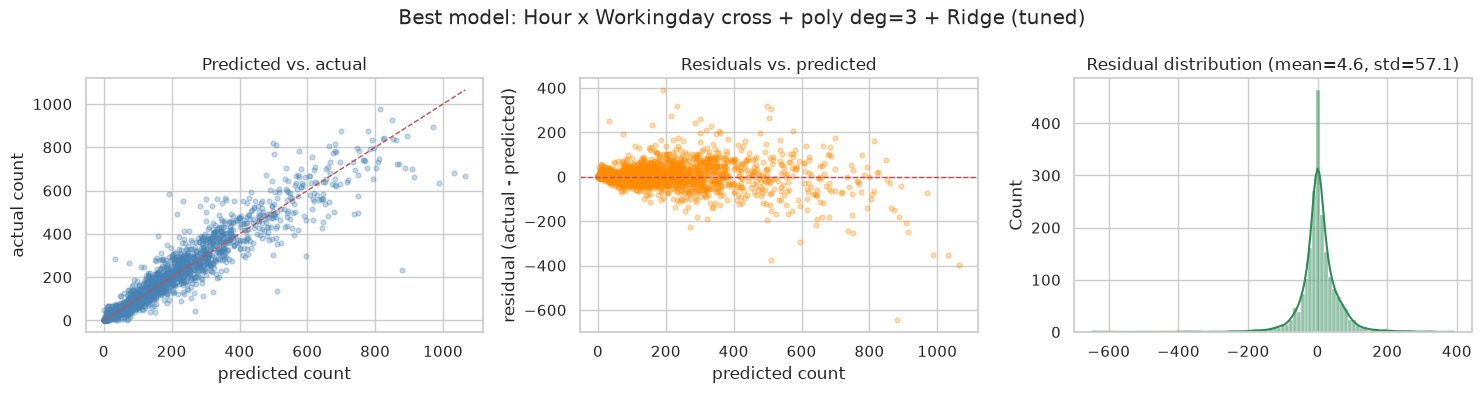

In [44]:
residuals = y_val.values - best_val_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(best_val_pred, y_val.values, alpha=0.3, s=12, color="steelblue")
lims = [0, max(y_val.max(), best_val_pred.max())]
axes[0].plot(lims, lims, "r--", lw=1)
axes[0].set_xlabel("predicted count")
axes[0].set_ylabel("actual count")
axes[0].set_title("Predicted vs. actual")

axes[1].scatter(best_val_pred, residuals, alpha=0.3, s=12, color="darkorange")
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("predicted count")
axes[1].set_ylabel("residual (actual - predicted)")
axes[1].set_title("Residuals vs. predicted")

sns.histplot(residuals, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title(f"Residual distribution (mean={residuals.mean():.1f}, std={residuals.std():.1f})")

plt.suptitle(f"Best model: {BEST_NAME}")
plt.tight_layout()
plt.show()


### Q9 — Why does the winning model perform better?

1. During the EDA we found that ***hour*** doesn't just have a nonlinear relationship with `count` — it has a *different shape* on workdays than on non-workdays. A plain linear model, and even a polynomial model built only from cyclical encoding, can't fit that. The `hour * workingday` categorical cross fits it directly, letting the model learn both shapes correctly.
2. The categorical-cross approach beats the polynomial attempts because of its flexibility — the bottleneck was never the model's capacity, it was that polynomial terms on `hour_sin`/`hour_cos` were the wrong *kind* of feature for this interaction.

### Reflection Questions.

### Q10 — Why does RMSLE penalize under-predictions more gently than RMSE?
RMSLE compares log(1 + predicted value) with log(1 + actual value).

The log transformation is done first to compress large values, so very large numbers have less impact on the calculation.

In simple terms, RMSLE is more forgiving of under-predictions but can strongly penalize very large over-predictions.

For example, if the actual demand is 500 and we predict 0, the error is limited because log(1 + 0) = 0. But if the actual demand is 0 and we predict 10,000, log(1 + 10,000) creates a much larger error.

So, RMSLE is useful for demand forecasting because it focuses on the relative difference between predicted and actual values and helps avoid extremely large over-predictions.

### Q11 — What are the trade-offs between model simplicity and predictive power?
The results show a trade-off between simplicity and complexity.

The linear model is the simplest and has a small train/validation gap, but its validation score is the worst. This means it is too simple to capture the patterns in the data (underfitting).
The degree-2 polynomial model without regularization gets the best training score, but the gap between training and validation is larger. This means it learns the training data too closely (overfitting).
Ridge and Lasso regularization provide a balance between the two. The alpha value controls how much we reduce the model's complexity. A small alpha allows more complexity, while a large alpha makes the model simpler.
Simpler models are also faster, cheaper, and easier to explain.
So, the best model is not always the most complex one. We should choose a model that gives a good balance between accuracy, complexity, and generalization.

### Q12 — Why can't Linear Regression alone capture time-of-day effects effectively?

Linear regression assigns exactly one coefficient (one slope) to each input feature, so it can only describe a monotonic, constant-rate relationship between a feature and the target. `hour`'s relationship with `count` is a curve with at least two peaks and two troughs — no single slope can trace that shape. Linear regression's "one slope per feature" structure is the bottleneck, and the fix isn't a better solver or more regularization — it's handing the model the specific interaction feature it needs.


## Saving the output csv for test dataset.

#####  best model was Hour x Workingday cross + degree-3 continuous poly + Ridge (val RMSLE 0.4104)

In [45]:
# Best model: Hour x Workingday cross + degree-3 continuous poly + Ridge (val RMSLE 0.4104)
from sklearn.linear_model import Ridge
best_degree = 3
best_alpha = cross_results[best_degree]["model"].alpha_

X_full_proc = pd.concat([X_train_proc, X_val_proc]).reset_index(drop=True)
y_full_log1p = np.log1p(pd.concat([y_train, y_val]).reset_index(drop=True))

cross_full = make_hour_workingday_cross(
    np.concatenate([hour_tr, hour_va]), np.concatenate([wd_tr_raw, wd_va_raw]),
    columns=cross_tr.columns)
cross_test = make_hour_workingday_cross(
    test_raw["hour"].values, test_raw["workingday"].values, columns=cross_tr.columns)

poly_final = PolynomialFeatures(degree=best_degree, include_bias=False)
full_cont = poly_final.fit_transform(X_full_proc[CONT_COLS])
test_cont = poly_final.transform(X_test_proc[CONT_COLS])

X_full_final = np.hstack([X_full_proc[CROSS_CAT_COLS].values, cross_full.values, full_cont,
                           X_full_proc[CYCLIC_REST_COLS].values])
X_test_final = np.hstack([X_test_proc[CROSS_CAT_COLS].values, cross_test.values, test_cont,
                           X_test_proc[CYCLIC_REST_COLS].values])

assert not np.isnan(X_test_final).any(), \
    "NaN in test features - re-run the notebook from the top (stale kernel state)"

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_full_final, y_full_log1p)

test_pred = np.round(np.clip(np.expm1(final_model.predict(X_test_final)), 0, None)).astype(int)

submission = pd.DataFrame({
    "datetime": test_raw["datetime_original_str"],
    "count_predicted": test_pred,
})
assert submission["datetime"].tolist() == test_raw["datetime_original_str"].tolist()
assert not submission.isna().any().any()

submission.to_csv("Submission.csv", index=False)
print("submission.csv rows:", len(submission))
submission.head()


submission.csv rows: 2613


,datetime,count_predicted
0,05-06-2012 5:00,21
1,19-03-2011 19:00,132
2,02-04-2012 6:00,92
3,13-07-2012 20:00,504
4,09-11-2011 19:00,283
